VERİ SETİNİ YÜKLEME VE VERİYE GENEL BAKIŞ
1-) Veri setinin sütunlarını tanımak
2-) Korelasyon analizi ile önemli değişkenleri belirlemek


In [1]:
import pandas as pd 
df = pd.read_csv("C:/Users/PC/Desktop/heart_disease.zip")

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [9]:
df.groupby("sex", observed=False)["age"].mean()

sex
0    55.849359
1    53.814867
Name: age, dtype: float64

In [10]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

İLERİ DÜZEY MAKİNE ÖĞRENMESİ 

<Axes: >

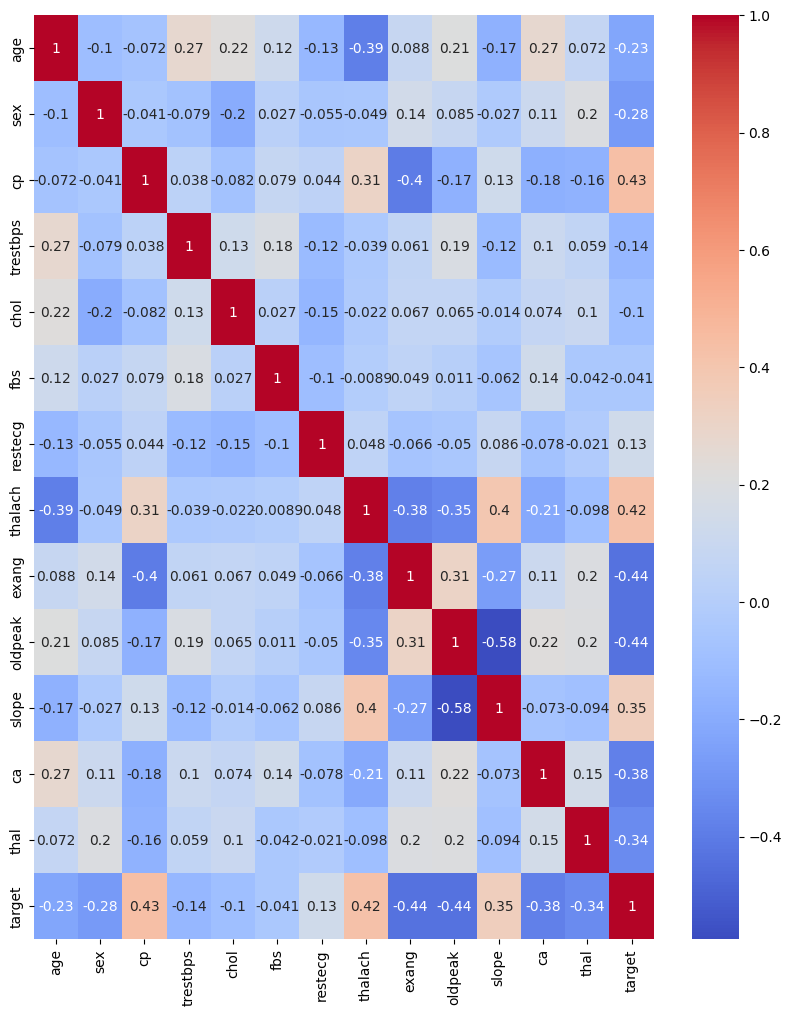

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(10,12))
sns.heatmap(corr, annot=True, cmap="coolwarm")


#####    VERİ ÖN İŞLEME :
##### * Sürekli değişkenleri ölçeklendirdik 
##### * Kategorik(ordinal) değişkenlere one-hot encoding uyguladık.

In [12]:
# Sürekli değişkenleri ölçeklendirme işlemi (1)
from sklearn.preprocessing import StandardScaler

# Sürekli değişkenler
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Ölçeklendirici (Scaler) tanımla
scaler = StandardScaler()

# Sürekli değişkenleri ölçeklendir
df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [13]:
# Kategorik değişkenler için one-hot encoding dönüşümü (2)
#Kategorik değişkenler 
categorical_features = ["sex", "cp","restecg", "slope", "thal", "ca"]

# One-hot encoding
df = pd.get_dummies(df, columns = categorical_features, drop_first=True)

In [14]:
# Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
X = df.drop("target", axis = 1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
rf_clf = RandomForestClassifier(n_estimators = 200, random_state = 42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print("CONFUSİON MATRİX")
print(conf_matrix)

Accuracy:  1.0
CONFUSİON MATRİX
[[102   0]
 [  0 103]]


In [31]:
#KNN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Özellikler ve hedef değişken
X = df.drop("target", axis=1)
y = df["target"]

# Veriyi ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ölçekleme
scaler = StandardScaler()
"""
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

"""

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


# Modeli oluştur ve eğit
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Tahmin ve doğruluk
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Doğruluk:", accuracy)

Doğruluk: 0.8409090909090909


In [17]:
# SVM
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X = df.drop("target", axis = 1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

svm_clf = SVC(kernel = "linear", random_state = 42)
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81       102
           1       0.79      0.87      0.83       103

    accuracy                           0.82       205
   macro avg       0.82      0.82      0.82       205
weighted avg       0.82      0.82      0.82       205



In [18]:
# Gaussian Naive Bayes
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix


X = df.drop("target", axis = 1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_pred = nb_clf.predict(X_test)


print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("CONFUSİON MATRİX")
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       102
           1       0.77      0.87      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205

CONFUSİON MATRİX
[[75 27]
 [13 90]]


In [19]:
# Karar Ağaçları
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

tree_clf = DecisionTreeClassifier(criterion = "entropy", max_depth = 5, random_state = 42)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print("CONFUSİON MATRİX")
print(conf_matrix)

Accuracy: 0.9073170731707317
CONFUSİON MATRİX
[[95  7]
 [12 91]]


#### Veriyi Bölmek 

In [20]:
# Veri setini Eğitim ve Test setine ayırma
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

#### GridSearchCV ile optimize edilmiş Random Forest

In [21]:
# GridSearchCV ile optimize edilmiş Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


#Model oluşturmak

rf = RandomForestClassifier(random_state=42)

#GridSearchCV ile hiperparametre optimizasyonu
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1, 2, 4]
}

# GridSearchCV'yi başlat
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv=5,  n_jobs = -1, verbose = 2)
grid_search.fit(X_train, y_train)

# En iyi model ile tahmin yap
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

#Sonuçları değerlendirme
print("Doğruluk Skoru:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("CONFUSİON MATRİX")
print(conf_matrix)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Doğruluk Skoru: 0.9902597402597403
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       159
           1       1.00      0.98      0.99       149

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308

CONFUSİON MATRİX
[[159   0]
 [  3 146]]


In [22]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# XGBoost modelini oluştur
xgb_model = xgb.XGBClassifier(random_state = 42)

# XGBoost için hiperparametre optimizasyonu
param_grid = {
    "n_estimators" : [50, 100, 200],
    "learning_rate" : [0.01, 0.05, 0.2],
    "max_depth" : [3, 5, 7],
    "subsample" : [0.8, 1.0]
}

# GridSearchCV'yi başlat
grid_search_xgb = GridSearchCV(estimator = xgb_model, param_grid = param_grid, cv=5, n_jobs = -1, verbose = 2)
grid_search_xgb.fit(X_train, y_train)

#En iyi parametreleri yazdır
print("En iyi parametreler (XGBoost):", grid_search_xgb.best_params_)

#En iyi model ile tahnin yap
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

#Sonuçları değerlendirme
print("Doğruluk Skoru (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
En iyi parametreler (XGBoost): {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Doğruluk Skoru (XGBoost): 0.9707792207792207
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



In [23]:
!pip install xgboost

In [24]:
from sklearn.svm import SVC

# SVM modelini oluştur
svm_model = SVC(random_state=42)

# SVM için hiperparametre optimizasyonu
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# GridSearchCV'yi başlat
grid_search_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search_svm.fit(X_train, y_train)

# En iyi parametreleri yazdır
print("En iyi parametreler (SVM):", grid_search_svm.best_params_)

# En iyi model ile tahmin yap
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# Sonuçları değerlendirme
print("Doğruluk Skoru (SVM):", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))



from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(grid_search_svm.best_estimator_, X, y, cv=10)
print("Ortalama doğruluk:", np.mean(scores))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
En iyi parametreler (SVM): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Doğruluk Skoru (SVM): 0.9902597402597403
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       159
           1       1.00      0.98      0.99       149

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308

Ortalama doğruluk: 0.9883209594517419


In [25]:
"""
df['chol_per_age'] = df['chol'] / df['age']  # Kolesterolün yaşa göre oranı
df['bp_per_age'] = df['trestbps'] / df['age']  # Dinlenme tansiyonu yaşa göre
df['age_thalach_ratio'] = df['thalach'] / df['age']  # Maksimum nabzın yaşa göre oranı
df['bp_thalach_diff'] = df['trestbps'] - df['thalach']  # Dinlenme tansiyonu - maksimum nabız
df['oldpeak_per_age'] = df['oldpeak'] / df['age']  # ST depresyonunun yaşa göre oranı

"""

"\ndf['chol_per_age'] = df['chol'] / df['age']  # Kolesterolün yaşa göre oranı\ndf['bp_per_age'] = df['trestbps'] / df['age']  # Dinlenme tansiyonu yaşa göre\ndf['age_thalach_ratio'] = df['thalach'] / df['age']  # Maksimum nabzın yaşa göre oranı\ndf['bp_thalach_diff'] = df['trestbps'] - df['thalach']  # Dinlenme tansiyonu - maksimum nabız\ndf['oldpeak_per_age'] = df['oldpeak'] / df['age']  # ST depresyonunun yaşa göre oranı\n\n"

In [26]:
models_to_compare = {
    "Random Forest": rf_clf,
    "XGBoost": best_xgb,
    "SVM": nb_clf,
    "KNN": knn
}


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


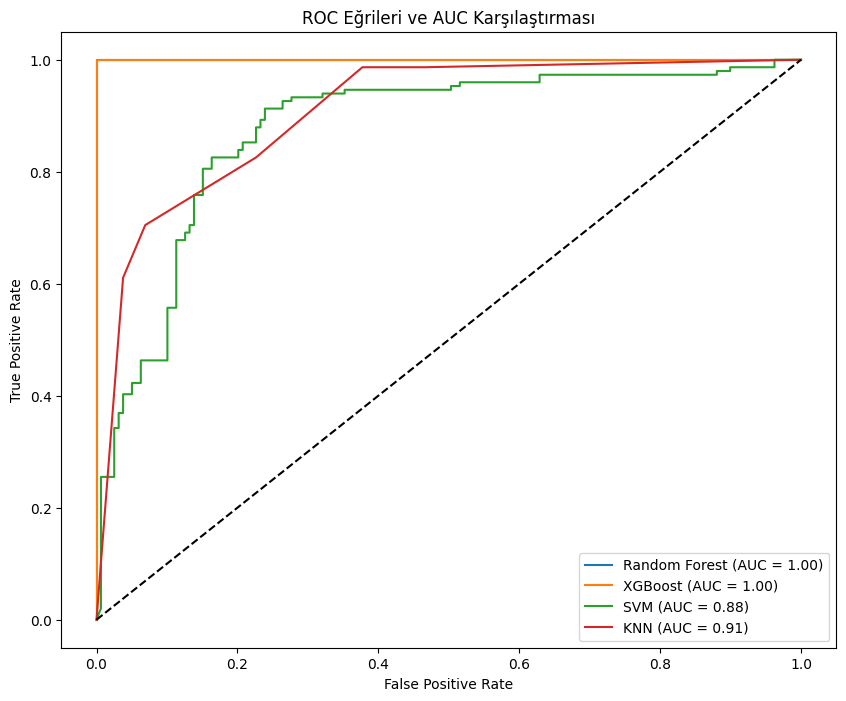

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for name, model in models_to_compare.items():
    # Modelin predict_proba veya decision_function kullanması gerekir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Rastgele tahmin çizgisi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrileri ve AUC Karşılaştırması')
plt.legend(loc='lower right')
plt.show()


PARTİAL DEPENDENCE PLOT / KISMİ BAĞIMLILIK GRAFİĞİ
MODEL AÇIKLANABİLİRLİĞİ

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

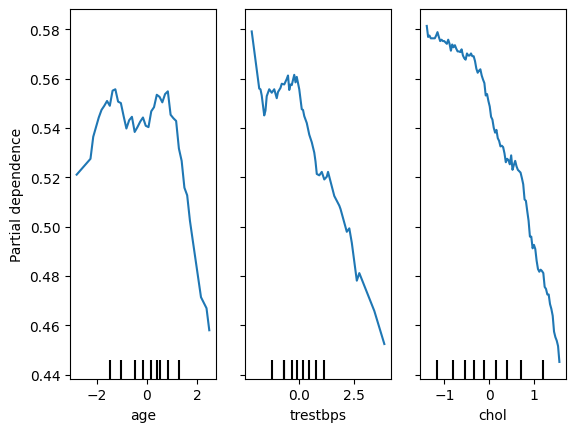

In [33]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# model: eğitilmiş modelin (örneğin rf_clf)
# X_train: eğitim verin (DataFrame veya numpy array)
# features: ilgilendiğin özelliklerin indexi ya da isimleri

features = [0, 1, 2]  # Örneğin ilk iki özellik

PartialDependenceDisplay.from_estimator(model, X_train, features)
plt.show()


### Yaşın etkisi doğrusal değildir. Önce bir artış gösterirken, belirli bir yaştan sonra düşüşe geçmektedir.

### İstirahat halindeki kan basıncının etkisi genellikle negatiftir. Kan basıncı arttıkça, modelin hedef değişken tahmini düşme eğilimindedir.

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature nam

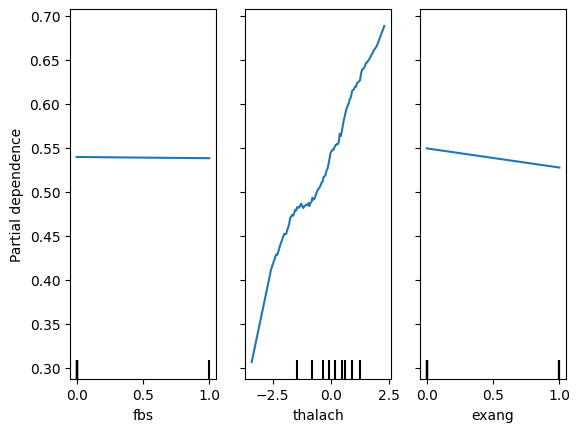

In [29]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# model: eğitilmiş modelin (örneğin rf_clf)
# X_train: eğitim verin (DataFrame veya numpy array)
# features: ilgilendiğin özelliklerin indexi ya da isimleri

features = [3, 4, 5 ]  # Örneğin ilk iki özellik

PartialDependenceDisplay.from_estimator(model, X_train, features)
plt.show()


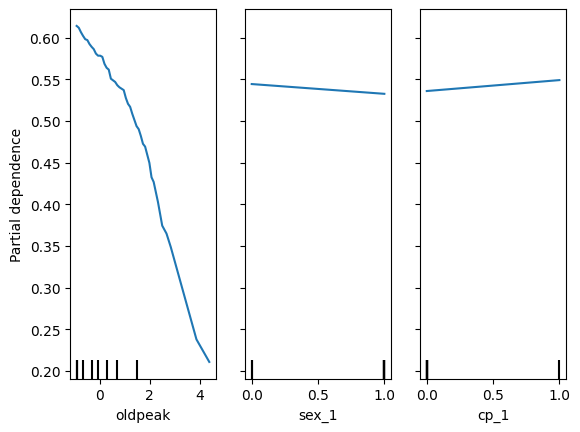

In [45]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# model: eğitilmiş modelin (örneğin rf_clf)
# X_train: eğitim verin (DataFrame veya numpy array)
# features: ilgilendiğin özelliklerin indexi ya da isimleri

features = [6, 7, 8]  # Örneğin ilk iki özellik

PartialDependenceDisplay.from_estimator(model, X_train, features)
plt.show()

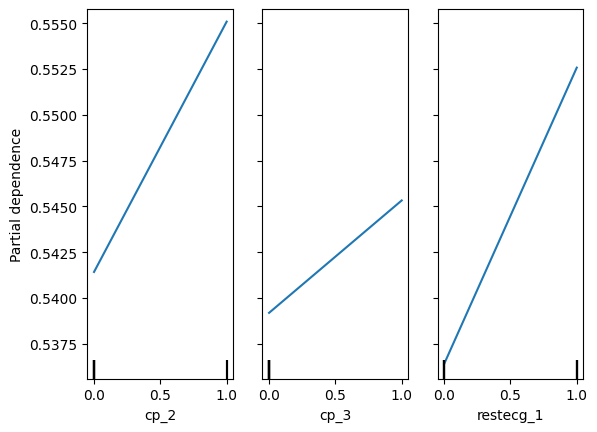

In [46]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# model: eğitilmiş modelin (örneğin rf_clf)
# X_train: eğitim verin (DataFrame veya numpy array)
# features: ilgilendiğin özelliklerin indexi ya da isimleri

features = [9, 10, 11]  # Örneğin ilk iki özellik

PartialDependenceDisplay.from_estimator(model, X_train, features)
plt.show()

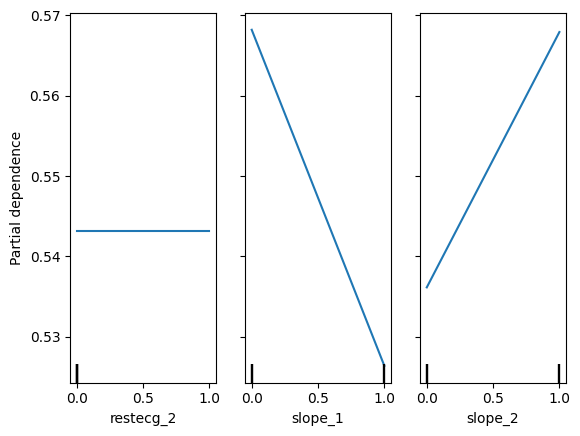

In [47]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# model: eğitilmiş modelin (örneğin rf_clf)
# X_train: eğitim verin (DataFrame veya numpy array)
# features: ilgilendiğin özelliklerin indexi ya da isimleri

features = [12, 13, 14]  # Örneğin ilk iki özellik

PartialDependenceDisplay.from_estimator(model, X_train, features)
plt.show()

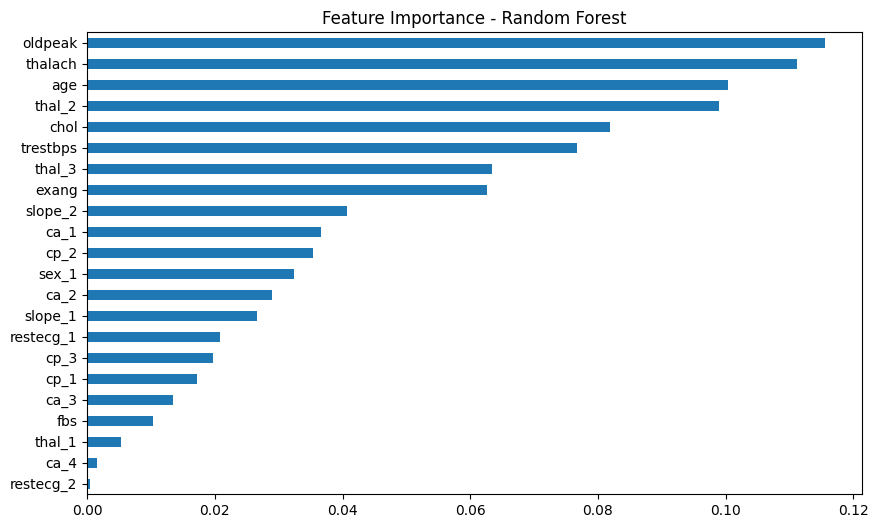

In [24]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.show()

In [30]:
df.head()

,age,trestbps,chol,fbs,thalach,exang,oldpeak,target,sex_1,cp_1,...,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
0,-0.268437,-0.377636,-0.659332,0,0.821321,0,-0.060888,0,True,False,...,False,False,True,False,False,True,False,True,False,False
1,-0.158157,0.479107,-0.833861,1,0.255968,1,1.727137,0,True,False,...,False,False,False,False,False,True,False,False,False,False
2,1.716595,0.764688,-1.396233,0,-1.048692,1,1.301417,0,True,False,...,False,False,False,False,False,True,False,False,False,False
3,0.724079,0.936037,-0.833861,0,0.516900,0,-0.912329,0,True,False,...,False,False,True,False,False,True,True,False,False,False
4,0.834359,0.364875,0.930822,1,-1.874977,0,0.705408,0,False,False,...,False,True,False,False,True,False,False,False,True,False
